In [82]:
#dataset or scaler maine verify karne ke baad kaam kiya hai isliye maine vo wala code nahi rakha, i call it optimization
import pandas as pd
import joblib
import numpy as np
from sklearn.model_selection import (train_test_split,GridSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import (XGBClassifier,plot_importance)
from sklearn.metrics import(
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
confusion_matrix,
)
import shap
import matplotlib.pyplot as plt
import xgboost as xgb
import os
print(os.cpu_count())

print("Imports done correctly")

12
Imports done correctly


D:\Rishabh\brr\4bandebrr\aslikaambrr\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df=pd.read_csv("../data/churn_ml_ready.csv")
print("done")
X=df.drop("churn_value",axis=1)     #Feature Matrix
y=df["churn_value"]                 #Target Vector
print(X.shape,y.shape)
print(df.memory_usage(deep=True).sum() / 1024**2) #no of columns bahut jyada hai but managable, ye line chaapa hu

done
(7043, 1161) (7043,)
62.4388313293457


In [3]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)# X y ko split or stratify kiya
print("X_train.shape",X_train.shape)
print("X_test.shape",X_test.shape)
print("y_train.shape",y_train.shape)
print("y_test.shape",y_test.shape)

X_train.shape (5634, 1161)
X_test.shape (1409, 1161)
y_train.shape (5634,)
y_test.shape (1409,)


In [4]:
#stratification check
print(y_train.value_counts(normalize=True)*100)
print(y_test.value_counts(normalize=True)*100)
#73 27 almost

churn_value
0    73.464679
1    26.535321
Name: proportion, dtype: float64
churn_value
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [5]:
#Synthetic Minority Over-sampling Technique mane Big Smoke(SMOTE)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Synthetic Minority oversampling completed")

Synthetic Minority oversampling completed


In [6]:
#class balance check
print("original y_train class balance",y_train.value_counts(normalize=True)*100)
print("SMOTE y_train class balance",y_train_smote.value_counts(normalize=True)*100)

#check shape
print("original X_train shape ",X_train.shape)
print("original y_train shape ",y_train.shape)

print("SMOTE X_train shape ",X_train_smote.shape)
print("SMOTE y_train shape ",y_train_smote.shape)

original y_train class balance churn_value
0    73.464679
1    26.535321
Name: proportion, dtype: float64
SMOTE y_train class balance churn_value
0    50.0
1    50.0
Name: proportion, dtype: float64
original X_train shape  (5634, 1161)
original y_train shape  (5634,)
SMOTE X_train shape  (8278, 1161)
SMOTE y_train shape  (8278,)


In [10]:
#Logistic Regression Model
logreg = LogisticRegression(random_state=42,max_iter=90).fit(X_train_smote, y_train_smote)
print(logreg.n_iter_)# model 81 iterations pe hi converge ho gya
print("Logistic Model Trained successfully")

[81]
Logistic Model Trained successfully


In [11]:
y_pred_lr = logreg.predict(X_test)
y_pred_lr_proba=logreg.predict_proba(X_test)[:,-1]#predictions of Logistic Regression
print("Logistic Regression has generated a prediction")

Logistic Regression has generated a prediction


In [12]:
# logistic regression model stats

print("\nLogistic Regression Model Stats\n")
accuracy_lr=accuracy_score(y_test,y_pred_lr)
precision_lr=precision_score(y_test,y_pred_lr)
recall_lr=recall_score(y_test,y_pred_lr)
f1_lr=f1_score(y_test,y_pred_lr)
roc_auc_lr=roc_auc_score(y_test,y_pred_lr_proba)
cm_lr=confusion_matrix(y_test,y_pred_lr)

print("accuracy:",accuracy_lr)
print("precision:",precision_lr)
print("recall:",recall_lr)
print("f1:",f1_lr)
print("roc_auc:",roc_auc_lr)
print("confusion_matrix:",cm_lr)


Logistic Regression Model Stats

accuracy: 0.9176721078779276
precision: 0.8161764705882353
recall: 0.8903743315508021
f1: 0.8516624040920716
roc_auc: 0.9740473791624688
confusion_matrix: [[960  75]
 [ 41 333]]


In [13]:
#Random Forest Model
rf=RandomForestClassifier(n_estimators=500,random_state=42,n_jobs=-1)
rf.fit(X_train_smote,y_train_smote)
print("Random Forest Trained successfully")

Random Forest Trained successfully


In [14]:
y_pred_rf=rf.predict(X_test)
y_pred_rf_proba=rf.predict_proba(X_test)[:,-1]#Random Forest Prediction
print("Random Forest has generated a prediction")

Random Forest has generated a prediction


In [17]:
#Random Forest Stats
accuracy_rf=accuracy_score(y_test,y_pred_rf)
precision_rf=precision_score(y_test,y_pred_rf)
recall_rf=recall_score(y_test,y_pred_rf)
f1_rf=f1_score(y_test,y_pred_rf)
roc_auc_rf=roc_auc_score(y_test,y_pred_rf_proba)
cm_rf=confusion_matrix(y_test,y_pred_rf)

print("Random Forest Model Stats\n")
print("accuracy:",accuracy_rf)
print("precision:",precision_rf)
print("recall:",recall_rf)
print("f1:",f1_rf)
print("roc_auc:",roc_auc_rf)
print("confusion_matrix:",cm_rf)

Random Forest Model Stats

accuracy: 0.9205110007097232
precision: 0.8411458333333334
recall: 0.8636363636363636
f1: 0.8522427440633246
roc_auc: 0.9587395696091349
confusion_matrix: [[974  61]
 [ 51 323]]


In [18]:
#XGBoost Model
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(
    X_train_smote,
    y_train_smote
)
print("XGBoost trained successfully")

XGBoost trained successfully


In [19]:
#XGB Model Prediction
y_pred_xgb=xgb.predict(X_test)
y_pred_xgb_proba=xgb.predict_proba(X_test)[:,-1]
print("XGBoost has generated a prediction")

XGBoost has generated a prediction


In [20]:
accuracy_xgb=accuracy_score(y_test,y_pred_xgb)
precision_xgb=precision_score(y_test,y_pred_xgb)
recall_xgb=recall_score(y_test,y_pred_xgb)
f1_xgb=f1_score(y_test,y_pred_xgb)
roc_auc_xgb=roc_auc_score(y_test,y_pred_xgb_proba)
cm_xgb=confusion_matrix(y_test,y_pred_xgb)

print("XGBoost Model Stats\n")
print("accuracy:",accuracy_xgb)
print("precision:",precision_xgb)
print("recall:",recall_xgb)
print("f1:",f1_xgb)
print("roc_auc:",roc_auc_xgb)
print("confusion_matrix:",cm_xgb)

XGBoost Model Stats

accuracy: 0.9226401703335699
precision: 0.8223844282238443
recall: 0.9037433155080213
f1: 0.8611464968152867
roc_auc: 0.9807176625590949
confusion_matrix: [[962  73]
 [ 36 338]]


XGBoost performs best of all 3 in all major cases

F1 score is going to be optimized
: precision is slightly down in XGBoost as compared to Random Forest
: Recall is my main objective to optimize for minimizing false flags
: F1 being harmonic mean of the two,sits perfectly between both levels as the balance between both

In [21]:
#GridSearchCV Fine-Tuning XGBoost
parameter_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}
print("this is initial parameter grid to find ranges of parameters for better performance we can fine tune it precisely within the new found values to make a better model")

this is initial parameter grid to find ranges of parameters for better performance we can fine tune it precisely within the new found values to make a better model


In [24]:

scoring_metrics = {
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc"
}

xgb_tuned=XGBClassifier(
    random_state=42,
    eval_metric="logloss",
)
grid_search=GridSearchCV(
    estimator=xgb_tuned,
    param_grid=parameter_grid,
    scoring=scoring_metrics,
    refit="f1",
    cv=5,
    n_jobs=-1,
    verbose=2
)
print("model object created successfully,now the waiting game begins")

model object created successfully,now the waiting game begins


In [33]:
#model training begins
grid_search.fit(X_train_smote,y_train_smote)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'f1': 'f1', 'precision': 'precision', 'recall': 'recall', 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the ve

In [25]:
#finding out best parameters
print("best parameters found using grid search",grid_search.best_params_)
print("best CV F1 score",grid_search.best_score_)


AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

best parameters were

colsample_bytree: 1.0

learning_rate: 0.05

max_depth: 8(edge)

n_estimators: 500(edge)

subsample: 0.8




In [33]:
#results
result = pd.DataFrame(grid_search.cv_results_)

result.sort_values(
    "mean_test_f1",
    ascending=False
)[[
    "mean_test_f1",
    "param_n_estimators",
    "param_max_depth",
    "param_learning_rate",
    "param_subsample",
    "param_colsample_bytree"
]].head(10)

AttributeError: 'GridSearchCV' object has no attribute 'cv_results_'

above values states model prefers

depth=8

500 trees


yet both features sit at the edges we only target these specifically, the rest parameters have improved F1 by very insignificant amounts

In [28]:
#Targeting Required Parameters now
parameter_grid_refined={
    "n_estimators":[500,600,700],
    "max_depth":[8,9,10],
    "learning_rate":[0.03,0.05],
    "subsample":[0.7,0.8],
    "colsample_bytree":[0.8,1.0],
}

grid_search_refined=GridSearchCV(                           #<-------------------------culprit code i reran without refitting
    estimator=xgb_tuned,
    param_grid=parameter_grid_refined,
    scoring=scoring_metrics,
    refit="f1",
    cv=5,
    n_jobs=-1,
    verbose=3,
)
print("now last hyperparameter tuning ")

now last hyperparameter tuning 


In [38]:
grid_search_refined.fit(X_train_smote,y_train_smote)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.03, 0.05], 'max_depth': [8, 9, ...], 'n_estimators': [500, 600, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'f1': 'f1', 'precision': 'precision', 'recall': 'recall', 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: t

In [52]:
#Round 2 results
print(grid_search_refined.best_params_)
print(grid_search_refined.best_score_)

results_refined=pd.DataFrame(
grid_search_refined.cv_results_).sort_values("mean_test_f1",ascending=False).head(10)

print(results_refined)

{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 10, 'n_estimators': 500, 'subsample': 0.7}
0.9548554425263095
    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
12      35.413583      0.451552         0.446864        0.016726   
15      42.147628      0.716147         0.485433        0.021907   
14      43.043785      0.387996         0.480477        0.018624   
26      40.791478      0.651398         0.448355        0.037678   
55      31.972829      0.285330         0.420761        0.034394   
54      33.469974      0.811293         0.438758        0.045511   
49      35.060245      0.686115         0.529917        0.153010   
41      43.311494      0.384630         0.459958        0.026850   
38      38.684748      0.756482         0.439817        0.033695   
9       39.408853      0.398708         0.504425        0.061257   

    param_colsample_bytree  param_learning_rate  param_max_depth  \
12                     0.8                 0.03            

model improved by 0.064% in F1 scores
i have pushed hyperparameter tuning to maximum level





In [42]:
#do not touch this cell again

#sone jaa rha hu
#joblib.dump(grid_search_refined,'model.pkl')#<----this also ran because i tried joblib.load in this same cell causing overwrite in model.pkl
#print("model saved kal ke liye")

#agla din
#grid_search_refined=joblib.load("model.pkl")
#print("model brrr")
#print(grid_search_refined.__dict__.keys())
# i just loaded this cell again and accidently lost my grid_search object but i still have best hyperparameters so i will create the model again from the given hyperparameters

model saved kal ke liye
model brrr
dict_keys(['scoring', 'estimator', 'n_jobs', 'refit', 'cv', 'verbose', 'pre_dispatch', 'error_score', 'return_train_score', 'param_grid'])


In [6]:
#model recovery by recreating the best hyperparameterized model from memory
best_xgb=XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=500,
    max_depth=10,
    subsample=0.7,
    colsample_bytree=0.8,
    learning_rate=0.03,
)


In [7]:
#fitting the recovered model
best_xgb.fit(X_train_smote,y_train_smote)
print("model recovery successful")

model recovery successful


In [8]:
y_pred_best_xgb=best_xgb.predict(X_test)
y_pred_best_xgb_proba=best_xgb.predict_proba(X_test)[:,-1]
print("predictions done successfully")

predictions done successfully


In [11]:
#final XGBoost Model Stats
accuracy_best_xgb=accuracy_score(y_test,y_pred_best_xgb)
precision_best_xgb=precision_score(y_test,y_pred_best_xgb)
recall_best_xgb=recall_score(y_test,y_pred_best_xgb)
f1_best_xgb=f1_score(y_test,y_pred_best_xgb)
roc_auc_best_xgb=roc_auc_score(y_test,y_pred_best_xgb_proba)
confusion_matrix_best_xgb=confusion_matrix(y_test,y_pred_best_xgb)

print("accuracy:",accuracy_best_xgb)
print("precision:",precision_best_xgb)
print("recall:",recall_best_xgb)
print("f1:",f1_best_xgb)
print("roc_auc:",roc_auc_best_xgb)
print("confusion_matrix:",confusion_matrix_best_xgb)

accuracy: 0.9311568488289567
precision: 0.8578811369509044
recall: 0.8877005347593583
f1: 0.8725361366622865
roc_auc: 0.981807848304012
confusion_matrix: [[980  55]
 [ 42 332]]


In [12]:
feature_importance=pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":best_xgb.feature_importances_,
})
feature_importance=feature_importance.sort_values(by="Importance",ascending=False)
feature_importance.head(20)

,Feature,Importance
22,contract_numeric,0.081754
16,churn_score,0.056767
561,city_Lemoore,0.039677
3,dependents,0.038597
427,city_Guatay,0.027371
970,city_Smith River,0.026571
24,internet_service_Fiber Optic,0.024504
597,city_Lotus,0.023929
878,city_Roseville,0.021528
742,city_Ontario,0.020904


In [13]:
city_features = feature_importance[
    feature_importance["Feature"].str.startswith("city_")
]

print("Number of city features:", len(city_features))

print("Total city importance:",
      city_features["Importance"].sum())

Number of city features: 1128
Total city importance: 0.66891485


city importance leads up to 66.8% which is a bit concerning given that we have 1128 cities and only approx 8k records of rows

city metrics have very low amount of entries to support their usability in predicting the outcome and yet they take substantial amount of feature importance

i must verify this by training another model without cities and while using the same hyperparameters,if significant changes appear, i will keep the cities as it is, or else i will remove the unnecessary noise

In [95]:
#Recreating test and train datasets from original DF and removing cities
#also splitting train data into train and validate data for future threshold optimization
city_cols=[col for col in X_train.columns if col.startswith("city_")]
X_train_nocity=X_train.drop(columns=city_cols)
X_test_nocity=X_test.drop(columns=city_cols)
print("X_train_nocity",X_train_nocity.shape)
print("X_test_nocity",X_test_nocity.shape)

#Train data split
X_train_nocity_sub,X_val_nocity,y_train_nocity_sub,y_val_nocity=train_test_split(
    X_train_nocity,
    y_train,
    random_state=42,
    stratify=y_train,
    test_size=0.2,
)
print("X_train_nocity_sub",X_train_nocity_sub.shape)
print("X_val_nocity",X_val_nocity.shape)
print("y_train_nocity_sub",y_train_nocity_sub.shape)
print("y_val_nocity",y_val_nocity.shape)

X_train_nocity (5634, 33)
X_test_nocity (1409, 33)
X_train_nocity_sub (4507, 33)
X_val_nocity (1127, 33)
y_train_nocity_sub (4507,)
y_val_nocity (1127,)


In [16]:
#SMOTE ON NO-CITY DataFrame to address class imbalance issue
smote=SMOTE(random_state=42)
X_train_nocity_sub_smote,y_train_nocity_sub_smote=smote.fit_resample(X_train_nocity_sub,y_train_nocity_sub)

In [17]:
print("X_train_nocity_sub_smote",X_train_nocity_sub_smote.shape)
print("y_train_nocity_sub_smote",y_train_nocity_sub_smote.shape)
print("y_train_nocity_sub_smote values",y_train_nocity_sub_smote.value_counts())

X_train_nocity_sub_smote (6622, 33)
y_train_nocity_sub_smote (6622,)
y_train_nocity_sub_smote values churn_value
0    3311
1    3311
Name: count, dtype: int64


Training subset        : 4507 rows

After SMOTE            : 6622 rows

Class 0                : 3311

Class 1                : 3311

Validation set         : 1127 rows

 Test set              : 1409 rows

In [19]:
#training XGBoost on previously found best hyperparameters and applying GridCV later.
xgb_nocity=XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=500,
    max_depth=10,
    subsample=0.7,
    colsample_bytree=0.8,
    learning_rate=0.03,
)
print("Nocity XGB Model Object Created")

Nocity XGB Model Object Created


In [20]:
xgb_nocity.fit(X_train_nocity_sub_smote,y_train_nocity_sub_smote)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [22]:
X_val_nocity_pred=xgb_nocity.predict(X_val_nocity)
X_val_nocity_pred_proba=xgb_nocity.predict_proba(X_val_nocity)[:,-1]

print("XGBoost Nocity Model Object Stats on Validation Set")
print("accuracy",accuracy_score(y_val_nocity,X_val_nocity_pred))
print("precision",precision_score(y_val_nocity,X_val_nocity_pred))
print("recall",recall_score(y_val_nocity,X_val_nocity_pred))
print("f1",f1_score(y_val_nocity,X_val_nocity_pred))
print("roc_auc",roc_auc_score(y_val_nocity,X_val_nocity_pred_proba))
print("confusion_matrix",confusion_matrix(y_val_nocity,X_val_nocity_pred))

XGBoost Nocity Model Object Stats on Validation Set
accuracy 0.9325643300798581
precision 0.8495297805642633
recall 0.9063545150501672
f1 0.8770226537216829
roc_auc 0.9836532402694973
confusion_matrix [[780  48]
 [ 28 271]]


In [27]:
parameter_grid_nocity_broad={
    "n_estimators": [200,400,600],
    "max_depth":[4,6,8,10],
    "learning_rate":[0.01,0.03,0.05],
    "subsample":[0.7,0.8,1.0],
    "colsample_bytree":[0.7,0.8,1.0],
}

In [36]:
xgb_nocity_base=XGBClassifier(
    random_state=42,
    eval_metric="logloss",
)

In [28]:
grid_search_nocity_broad=GridSearchCV(
    estimator=xgb_nocity_base,
    param_grid=parameter_grid_nocity_broad,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=2,
)

In [29]:
grid_search_nocity_broad.fit(X_train_nocity_sub_smote,y_train_nocity_sub_smote)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [4, 6, ...], 'n_estimators': [200, 400, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fo

saving the gridsearch only once so i dont lose it

In [30]:
#joblib.dump(grid_search_nocity_broad,"grid_search_nocity_broad.pkl")
#do not touch it again

['grid_search_nocity_broad.pkl']

In [38]:
print(grid_search_nocity_broad.best_params_)
print(grid_search_nocity_broad.best_score_)

{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 400, 'subsample': 0.8}
0.9528318868601625


In [39]:
results_nocity_broad=pd.DataFrame(grid_search_nocity_broad.cv_results_).sort_values(by=['mean_test_score'],ascending=False)

results_nocity_broad.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_learning_rate,param_max_depth,param_n_estimators,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
211,2.292250,0.070022,0.057003,0.008992,0.8,0.05,10,400,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.922844,0.946071,0.962801,0.963235,0.969208,0.952832,0.016857,1
178,3.593235,0.197993,0.069157,0.004355,0.8,0.03,10,600,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.922961,0.942085,0.963557,0.964706,0.970588,0.952779,0.017771,2
33,4.953140,0.169203,0.090581,0.008981,0.7,0.01,10,600,0.7,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.927122,0.943164,0.959825,0.962472,0.971260,0.952769,0.015722,3
35,4.424790,0.322087,0.068085,0.005379,0.7,0.01,10,600,1.0,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.923888,0.943164,0.959942,0.964654,0.971976,0.952725,0.017251,4
100,1.369340,0.045206,0.036944,0.001342,0.7,0.05,10,200,0.8,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.927711,0.943629,0.959883,0.963289,0.969072,0.952717,0.015090,5
31,3.857115,0.303731,0.080585,0.012835,0.7,0.01,10,400,0.8,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.928625,0.944785,0.957664,0.961001,0.970545,0.952524,0.014519,6
65,1.594806,0.107029,0.047502,0.021409,0.7,0.03,10,200,1.0,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.924003,0.943975,0.959302,0.963181,0.972018,0.952496,0.016888,7
58,2.032143,0.077398,0.046449,0.005082,0.7,0.03,8,400,0.8,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.922961,0.941358,0.962801,0.964706,0.970588,0.952483,0.017771,8
208,1.341683,0.047081,0.035098,0.003242,0.8,0.05,10,200,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.926205,0.939908,0.962692,0.963235,0.969875,0.952383,0.016559,9
105,3.416382,0.152216,0.080118,0.007309,0.7,0.05,10,600,0.7,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.919575,0.941815,0.963557,0.965416,0.971387,0.952350,0.019204,10


In [34]:
#final grid search cv attempt at xgb_nocity whatever the name of the model is, i need a better naming convention at this point
parameter_grid_nocity_fine={
    "n_estimators": [300,400,500],
    "max_depth":[9,10,11],
    "learning_rate":[0.04,0.05,0.06],
    "subsample":[0.7,0.8,0.9],
    "colsample_bytree":[0.7,0.8,0.9]
}

In [42]:
#im too scared to use the same base estimator again even though it is safe
xgb_nocity_fine=XGBClassifier(random_state=42,
    eval_metric="logloss" )
grid_search_nocity_fine=GridSearchCV(
    estimator=xgb_nocity_fine,
    param_grid=parameter_grid_nocity_fine,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=2,
)

In [43]:
grid_search_nocity_fine.fit(X_train_nocity_sub_smote,y_train_nocity_sub_smote)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.04, 0.05, ...], 'max_depth': [9, 10, ...], 'n_estimators': [300, 400, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each f

In [45]:
print(grid_search_nocity_fine.best_params_)
print(grid_search_nocity_fine.best_score_)

{'colsample_bytree': 0.8, 'learning_rate': 0.04, 'max_depth': 10, 'n_estimators': 400, 'subsample': 0.8}
0.9546692749346113


In [49]:
#loading the final GridSearchCV object
#do not touch this cell again
#joblib.dump(grid_search_nocity_fine,"grid_search_nocity_fine.pkl")

['grid_search_nocity_fine.pkl']

learning rate shifted a bit and the rest remained the same

now the best hyperparameters for xgb_nocity_fine are

{'colsample_bytree': 0.8, 'learning_rate': 0.04, 'max_depth': 10, 'n_estimators': 400, 'subsample': 0.8}


In [46]:
ggxgb_nocity_fine=XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=400,
    max_depth=10,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
)

xgb_nocity_fine.fit(X_train_nocity_sub_smote,y_train_nocity_sub_smote)
print("hyperparameter testing done with no city xgb model")

hyperparameter testing done with no city xgb model


In [51]:
#we only need validation probability right now for threshold optimizations
y_val_nocity_pred_proba=xgb_nocity_fine.predict_proba(X_val_nocity)[:,1]

In [58]:
threshold_result=[]
threshold_list=[0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
for i in threshold_list:
    y_nocity_pred_thresh=(y_val_nocity_pred_proba>=i).astype(int)
    threshold_result.append({
        "threshold":i,
        "precison": precision_score(y_val_nocity,y_nocity_pred_thresh),
        "recall": recall_score(y_val_nocity,y_nocity_pred_thresh),
        "f1": f1_score(y_val_nocity,y_nocity_pred_thresh)
    })

    threshold_df=pd.DataFrame(threshold_result).sort_values(by="f1",ascending=False)
    print(threshold_df)
    threshold_df.to_csv("thresholdbrr.csv",index=False)

   threshold  precison    recall        f1
0        0.3  0.816327  0.936455  0.872274
   threshold  precison    recall        f1
1       0.35  0.820588  0.933110  0.873239
0       0.30  0.816327  0.936455  0.872274
   threshold  precison    recall        f1
2       0.40  0.826866  0.926421  0.873817
1       0.35  0.820588  0.933110  0.873239
0       0.30  0.816327  0.936455  0.872274
   threshold  precison    recall        f1
3       0.45  0.833837  0.923077  0.876190
2       0.40  0.826866  0.926421  0.873817
1       0.35  0.820588  0.933110  0.873239
0       0.30  0.816327  0.936455  0.872274
   threshold  precison    recall        f1
4       0.50  0.846154  0.919732  0.881410
3       0.45  0.833837  0.923077  0.876190
2       0.40  0.826866  0.926421  0.873817
1       0.35  0.820588  0.933110  0.873239
0       0.30  0.816327  0.936455  0.872274
   threshold  precison    recall        f1
4       0.50  0.846154  0.919732  0.881410
5       0.55  0.851735  0.903010  0.876623
3       0.4

from the above experiment we found our best threshold was 0.5
so we have arrived at very final stage of our model training

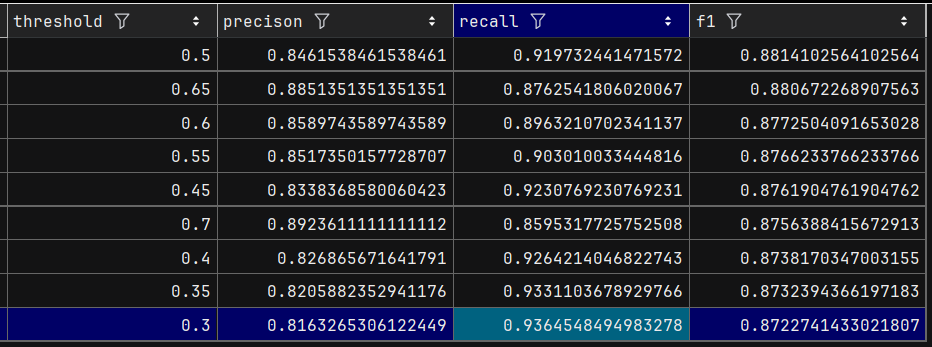

In [73]:
#applying smote on full training data
X_train_nocity_smote,y_train_nocity_smote=smote.fit_resample(X_train_nocity,y_train)

In [75]:
#resummoning my previous variables as i keep forgetting them
print("X_train_nocity",X_train_nocity.shape)
print("X_test_nocity",X_test_nocity.shape)
print("X_train_nocity_sub",X_train_nocity_sub.shape)
print("X_val_nocity",X_val_nocity.shape)
print("y_train_nocity_sub",y_train_nocity_sub.shape)
print("y_val_nocity",y_val_nocity.shape)
print("X_train_nocity_smote",X_train_nocity_smote.shape)
print("y_train_nocity_smote",y_train_nocity_smote.shape)
print("X_train_nocity_sub_smote",X_train_nocity_sub_smote.shape)
print("y_train_nocity_sub_smote",y_train_nocity_sub_smote.shape)
print("y_train_nocity_sub_smote values",y_train_nocity_sub_smote.value_counts())

X_train_nocity (5634, 33)
X_test_nocity (1409, 33)
X_train_nocity_sub (4507, 33)
X_val_nocity (1127, 33)
y_train_nocity_sub (4507,)
y_val_nocity (1127,)
X_train_nocity_smote (8278, 33)
y_train_nocity_smote (8278,)
X_train_nocity_sub_smote (6622, 33)
y_train_nocity_sub_smote (6622,)
y_train_nocity_sub_smote values churn_value
0    3311
1    3311
Name: count, dtype: int64


In [77]:
#final model tuning
xgb_final = XGBClassifier(
    colsample_bytree=0.8,
    learning_rate=0.04,
    max_depth=10,
    n_estimators=400,
    subsample=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_final.fit(
    X_train_nocity_smote,
    y_train_nocity_smote
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [80]:
y_nocity_test_pred = xgb_final.predict(X_test_nocity)
y_nocity_test_pred_proba = xgb_final.predict_proba(X_test_nocity)[:, 1]

In [81]:
print("Final XGBoost Model Stats")
print("accuracy",accuracy_score(y_test,y_nocity_test_pred))
print("precision",precision_score(y_test,y_nocity_test_pred))
print("recall",recall_score(y_test,y_nocity_test_pred))
print("f1",f1_score(y_test,y_nocity_test_pred))
print("roc_auc",roc_auc_score(y_test,y_nocity_test_pred_proba))
print("confusion matrix",confusion_matrix(y_test,y_nocity_test_pred))

Final XGBoost Model Stats
accuracy 0.9254790631653655
precision 0.8457583547557841
recall 0.8796791443850267
f1 0.8623853211009175
roc_auc 0.9813040894882328
confusion matrix [[975  60]
 [ 45 329]]


the previous model which had cities contributed around 66-67% features and yet after removing them we see a very small margin difference

it indicates services had the most say in the reason to churn than the location of the customers

Using SHAP to explain the predictions

In [86]:
explainer=shap.TreeExplainer(xgb_final)
shap_values=explainer.shap_values(X_test_nocity)
print("shap values shape",shap_values.shape)

shap values shape (1409, 33)


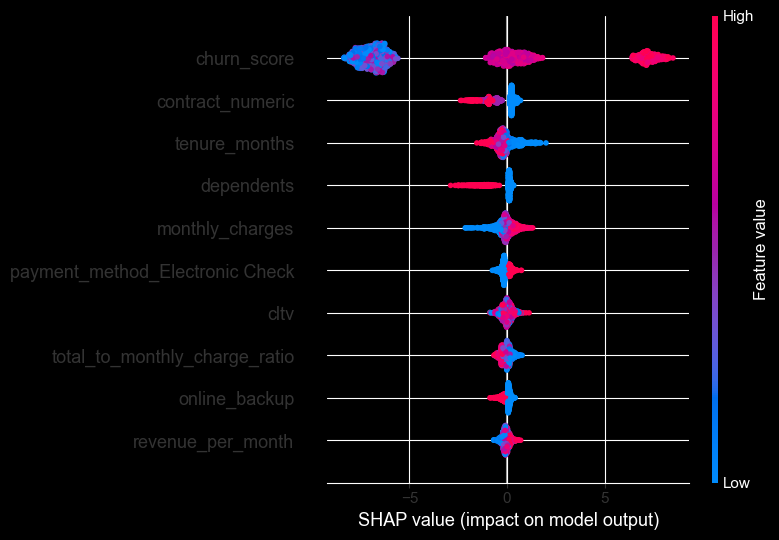

In [92]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test_nocity,
    max_display=10,
    show=False
)
plt.show()
plt.close()


Tips on reading this graph

RED represents High feature value

Blue represents Low feature value

Right side is positive churn

Left side is negative churn


In [93]:
#numerical Table of the above graph
feature_importance_shap = pd.DataFrame({
    "Feature": X_test_nocity.columns,
    "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0)
})

feature_importance_shap = feature_importance_shap.sort_values(
    by="Mean_Abs_SHAP",
    ascending=False
)

feature_importance_shap.head(10)

,Feature,Mean_Abs_SHAP
16,churn_score,5.009047
22,contract_numeric,0.564065
4,tenure_months,0.383463
3,dependents,0.383208
14,monthly_charges,0.301893
27,payment_method_Electronic Check,0.191706
17,cltv,0.187492
19,total_to_monthly_charge_ratio,0.182973
8,online_backup,0.151839
18,revenue_per_month,0.143328


In [108]:
X_full_nocity=X.drop(columns=city_cols)
X_full_nocity.shape
df.shape

(7043, 1162)

In [109]:
#scoring the dataset for adding churn_probability and predicted_churn
df["churn_probability"]=(xgb_final.predict_proba(X_full_nocity)[:,1])
df["predicted_churn"]=(df["churn_probability"]>=0.5).astype(int)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1544\3511803740.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["churn_probability"]=(xgb_final.predict_proba(X_full_nocity)[:,1])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1544\3511803740.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["predicted_churn"]=(df["churn_probability"]>=0.5).astype(int)


above is the performance warning, i dont know how to fix it, maybe .copy() might defragment it idk

the code still runs fine

In [119]:
#saving important things
#feature_engineered_scored_csv=df.to_csv("feature_engineered_scored.csv",index=False)


In [118]:
#joblib.dump(xgb_final,"xgb_final.pkl")

['xgb_final.pkl']